# Exploratory Data Analysis (EDA)

## IT Support Ticket Priority Prediction

### Objective

The objective of this exploratory data analysis is to understand the characteristics of IT support tickets, assess data quality, identify patterns related to ticket priority, and generate business insights that will support the development of a machine learning classification model.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
#Dataset Load

df = pd.read_csv("../data/Support_tickets.csv")

df.head()

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,org_users,region,region_cat,past_30d_tickets,past_90d_incidents,product_area,product_area_cat,booking_channel,booking_channel_cat,reported_by_role,reported_by_role_cat,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,126,APAC,3,2,0,mobile,3,web,1,support,1,2,5.45,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,101,AMER,1,2,3,analytics,5,chat,3,product_manager,3,24,2.50,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,71,APAC,3,3,1,notifications,6,chat,3,devops,2,1,3.33,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,100,AMER,1,2,2,analytics,5,chat,3,finance,4,25,2.93,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,332,AMER,1,5,1,analytics,5,web,1,support,1,28,3.26,6,0,0,0,0,neutral,2,442,low,1


In [4]:
#General Information
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 50,000
Columns: 33


,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,org_users,region,region_cat,past_30d_tickets,past_90d_incidents,product_area,product_area_cat,booking_channel,booking_channel_cat,reported_by_role,reported_by_role_cat,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,126,APAC,3,2,0,mobile,3,web,1,support,1,2,5.45,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,101,AMER,1,2,3,analytics,5,chat,3,product_manager,3,24,2.50,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,71,APAC,3,3,1,notifications,6,chat,3,devops,2,1,3.33,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,100,AMER,1,2,2,analytics,5,chat,3,finance,4,25,2.93,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,332,AMER,1,5,1,analytics,5,web,1,support,1,28,3.26,6,0,0,0,0,neutral,2,442,low,1


In [5]:
#Data Type
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ticket_id               50000 non-null  int64  
 1   day_of_week             50000 non-null  str    
 2   day_of_week_num         50000 non-null  int64  
 3   company_id              50000 non-null  int64  
 4   company_size            50000 non-null  str    
 5   company_size_cat        50000 non-null  int64  
 6   industry                50000 non-null  str    
 7   industry_cat            50000 non-null  int64  
 8   customer_tier           50000 non-null  str    
 9   customer_tier_cat       50000 non-null  int64  
 10  org_users               50000 non-null  int64  
 11  region                  50000 non-null  str    
 12  region_cat              50000 non-null  int64  
 13  past_30d_tickets        50000 non-null  int64  
 14  past_90d_incidents      50000 non-null  int64  
 

In [6]:
#Initial Data Exploration

df.describe().T

,count,mean,std,min,25%,50%,75%,max
ticket_id,50000.00,1000024999.50,14433.90,1000000000.00,1000012499.75,1000024999.50,1000037499.25,1000049999.00
day_of_week_num,50000.00,3.08,1.61,1.00,2.00,3.00,4.00,7.00
company_id,50000.00,100013.04,7.27,100001.00,100007.00,100013.00,100019.00,100025.00
company_size_cat,50000.00,1.90,0.80,1.00,1.00,2.00,3.00,3.00
industry_cat,50000.00,4.12,2.05,1.00,3.00,3.00,6.00,7.00
customer_tier_cat,50000.00,1.93,0.75,1.00,1.00,2.00,2.00,3.00
org_users,50000.00,1762.04,2266.44,71.00,126.00,547.00,4799.00,5757.00
region_cat,50000.00,1.97,0.81,1.00,1.00,2.00,3.00,3.00
past_30d_tickets,50000.00,3.82,2.78,0.00,2.00,3.00,5.00,19.00
past_90d_incidents,50000.00,1.85,1.47,0.00,1.00,2.00,3.00,12.00


In [7]:
#Categorical Variable Analysis
df.describe(include=["object", "string"]).T

,count,unique,top,freq
day_of_week,50000,7,Mon,11126
company_size,50000,3,Small,18901
industry,50000,7,saas_b2b,13107
customer_tier,50000,3,Plus,21967
region,50000,3,AMER,17103
product_area,50000,6,mobile,10003
booking_channel,50000,4,web,17590
reported_by_role,50000,5,support,23577
customer_sentiment,49094,3,neutral,32944
priority,50000,3,low,25000


In [8]:
#Null Values
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df)
) * 100

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
customer_sentiment,906,1.81
ticket_id,0,0.00
booking_channel,0,0.00
priority,0,0.00
description_length,0,0.00
customer_sentiment_cat,0,0.00
has_runbook,0,0.00
data_loss_flag,0,0.00
security_incident_flag,0,0.00
payment_impact_flag,0,0.00


In [9]:
#Duplicates
duplicates = df.duplicated().sum()

print(f"Duplicated rows: {duplicates}")

Duplicated rows: 0


In [10]:
#Dataset Size
print(f"Dataset contains {df.shape[0]:,} observations and {df.shape[1]} variables.")

Dataset contains 50,000 observations and 33 variables.


In [11]:
# ==========================
# Feature Classification
# ==========================

# Identifier columns
identifier_columns = [
    "ticket_id",
    "customer_id"
]

# Target variable
target_column = "priority"

# Remove identifiers and target
feature_columns = [
    col for col in df.columns
    if col not in identifier_columns + [target_column]
]

# Continuous numerical variables
continuous_features = []

# Binary variables (0/1)
binary_features = []

# Categorical variables
categorical_features = []

for column in feature_columns:

    if pd.api.types.is_numeric_dtype(df[column]):

        unique_values = df[column].dropna().unique()

        # Binary numeric variables
        if len(unique_values) == 2 and set(unique_values).issubset({0,1}):

            binary_features.append(column)

        else:

            continuous_features.append(column)

    else:

        categorical_features.append(column)

print(f"Continuous variables : {len(continuous_features)}")
print(f"Binary variables     : {len(binary_features)}")
print(f"Categorical variables: {len(categorical_features)}")

Continuous variables : 18
Binary variables     : 4
Categorical variables: 9


In [12]:
#List of numerical and categorical features
print("Continuous Features")
print(continuous_features)

print("\nBinary Features")
print(binary_features)

print("\nCategorical Features")
print(categorical_features)

Continuous Features
['day_of_week_num', 'company_id', 'company_size_cat', 'industry_cat', 'customer_tier_cat', 'org_users', 'region_cat', 'past_30d_tickets', 'past_90d_incidents', 'product_area_cat', 'booking_channel_cat', 'reported_by_role_cat', 'customers_affected', 'error_rate_pct', 'downtime_min', 'customer_sentiment_cat', 'description_length', 'priority_cat']

Binary Features
['payment_impact_flag', 'security_incident_flag', 'data_loss_flag', 'has_runbook']

Categorical Features
['day_of_week', 'company_size', 'industry', 'customer_tier', 'region', 'product_area', 'booking_channel', 'reported_by_role', 'customer_sentiment']


# 2. Target Variable Analysis

Understanding the distribution of the target variable is essential before building a classification model. This analysis helps identify potential class imbalance, understand the prevalence of each priority level, and determine whether additional preprocessing techniques may be required.

In [13]:
#Class Counts
priority_counts = df["priority"].value_counts().sort_index()

priority_counts

priority
high       7500
low       25000
medium    17500
Name: count, dtype: int64

In [14]:
#Percentage of each class
priority_percent = (
    df["priority"]
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
      .round(2)
)

priority_percent

priority
high     15.00
low      50.00
medium   35.00
Name: proportion, dtype: float64

In [15]:
#Table Summary
priority_summary = pd.DataFrame({
    "Count": priority_counts,
    "Percentage": priority_percent
})

priority_summary

,Count,Percentage
priority,,
high,7500,15.00
low,25000,50.00
medium,17500,35.00


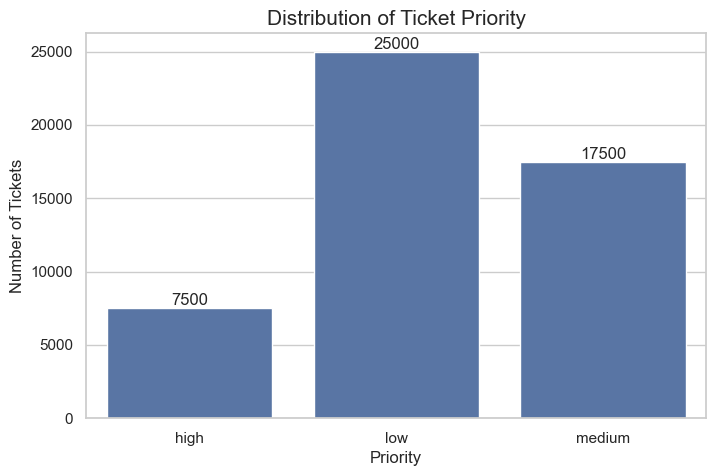

In [16]:
#Priority Visualization
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="priority",
    order=sorted(df["priority"].unique())
)

plt.title("Distribution of Ticket Priority", fontsize=15)
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

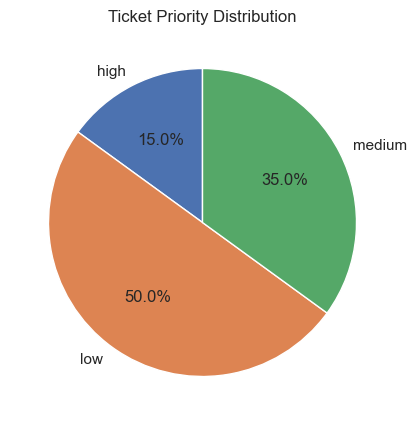

In [17]:
#Pie Chart - Visualization

plt.figure(figsize=(8,5))

plt.pie(
    priority_counts,
    labels=priority_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Ticket Priority Distribution")

plt.show()

### Insights

- The target variable appears relatively balanced across all priority levels. Nonetheless, "Low severity" has a big pressence.
- Despite the 50% for the "Low severity" category, the dataset does not have a single class dominating, this reduces the likelihood of severe class imbalance during model training.
- Since each priority category is well represented, standard classification algorithms can be evaluated before considering resampling techniques.

# 3. Univariate Analysis

The objective of this section is to analyze each feature independently to understand its distribution, variability, and potential anomalies. This helps identify outliers, skewed distributions, and categorical patterns that may influence ticket priority.

## 3.1 Numerical Feature Analysis

In [18]:
#Descriptive Statistics

df[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
day_of_week_num,50000.00,3.08,1.61,1.00,2.00,3.00,4.00,7.00
company_id,50000.00,100013.04,7.27,100001.00,100007.00,100013.00,100019.00,100025.00
company_size_cat,50000.00,1.90,0.80,1.00,1.00,2.00,3.00,3.00
industry_cat,50000.00,4.12,2.05,1.00,3.00,3.00,6.00,7.00
customer_tier_cat,50000.00,1.93,0.75,1.00,1.00,2.00,2.00,3.00
org_users,50000.00,1762.04,2266.44,71.00,126.00,547.00,4799.00,5757.00
region_cat,50000.00,1.97,0.81,1.00,1.00,2.00,3.00,3.00
past_30d_tickets,50000.00,3.82,2.78,0.00,2.00,3.00,5.00,19.00
past_90d_incidents,50000.00,1.85,1.47,0.00,1.00,2.00,3.00,12.00
product_area_cat,50000.00,3.57,1.79,1.00,2.00,3.00,5.00,6.00


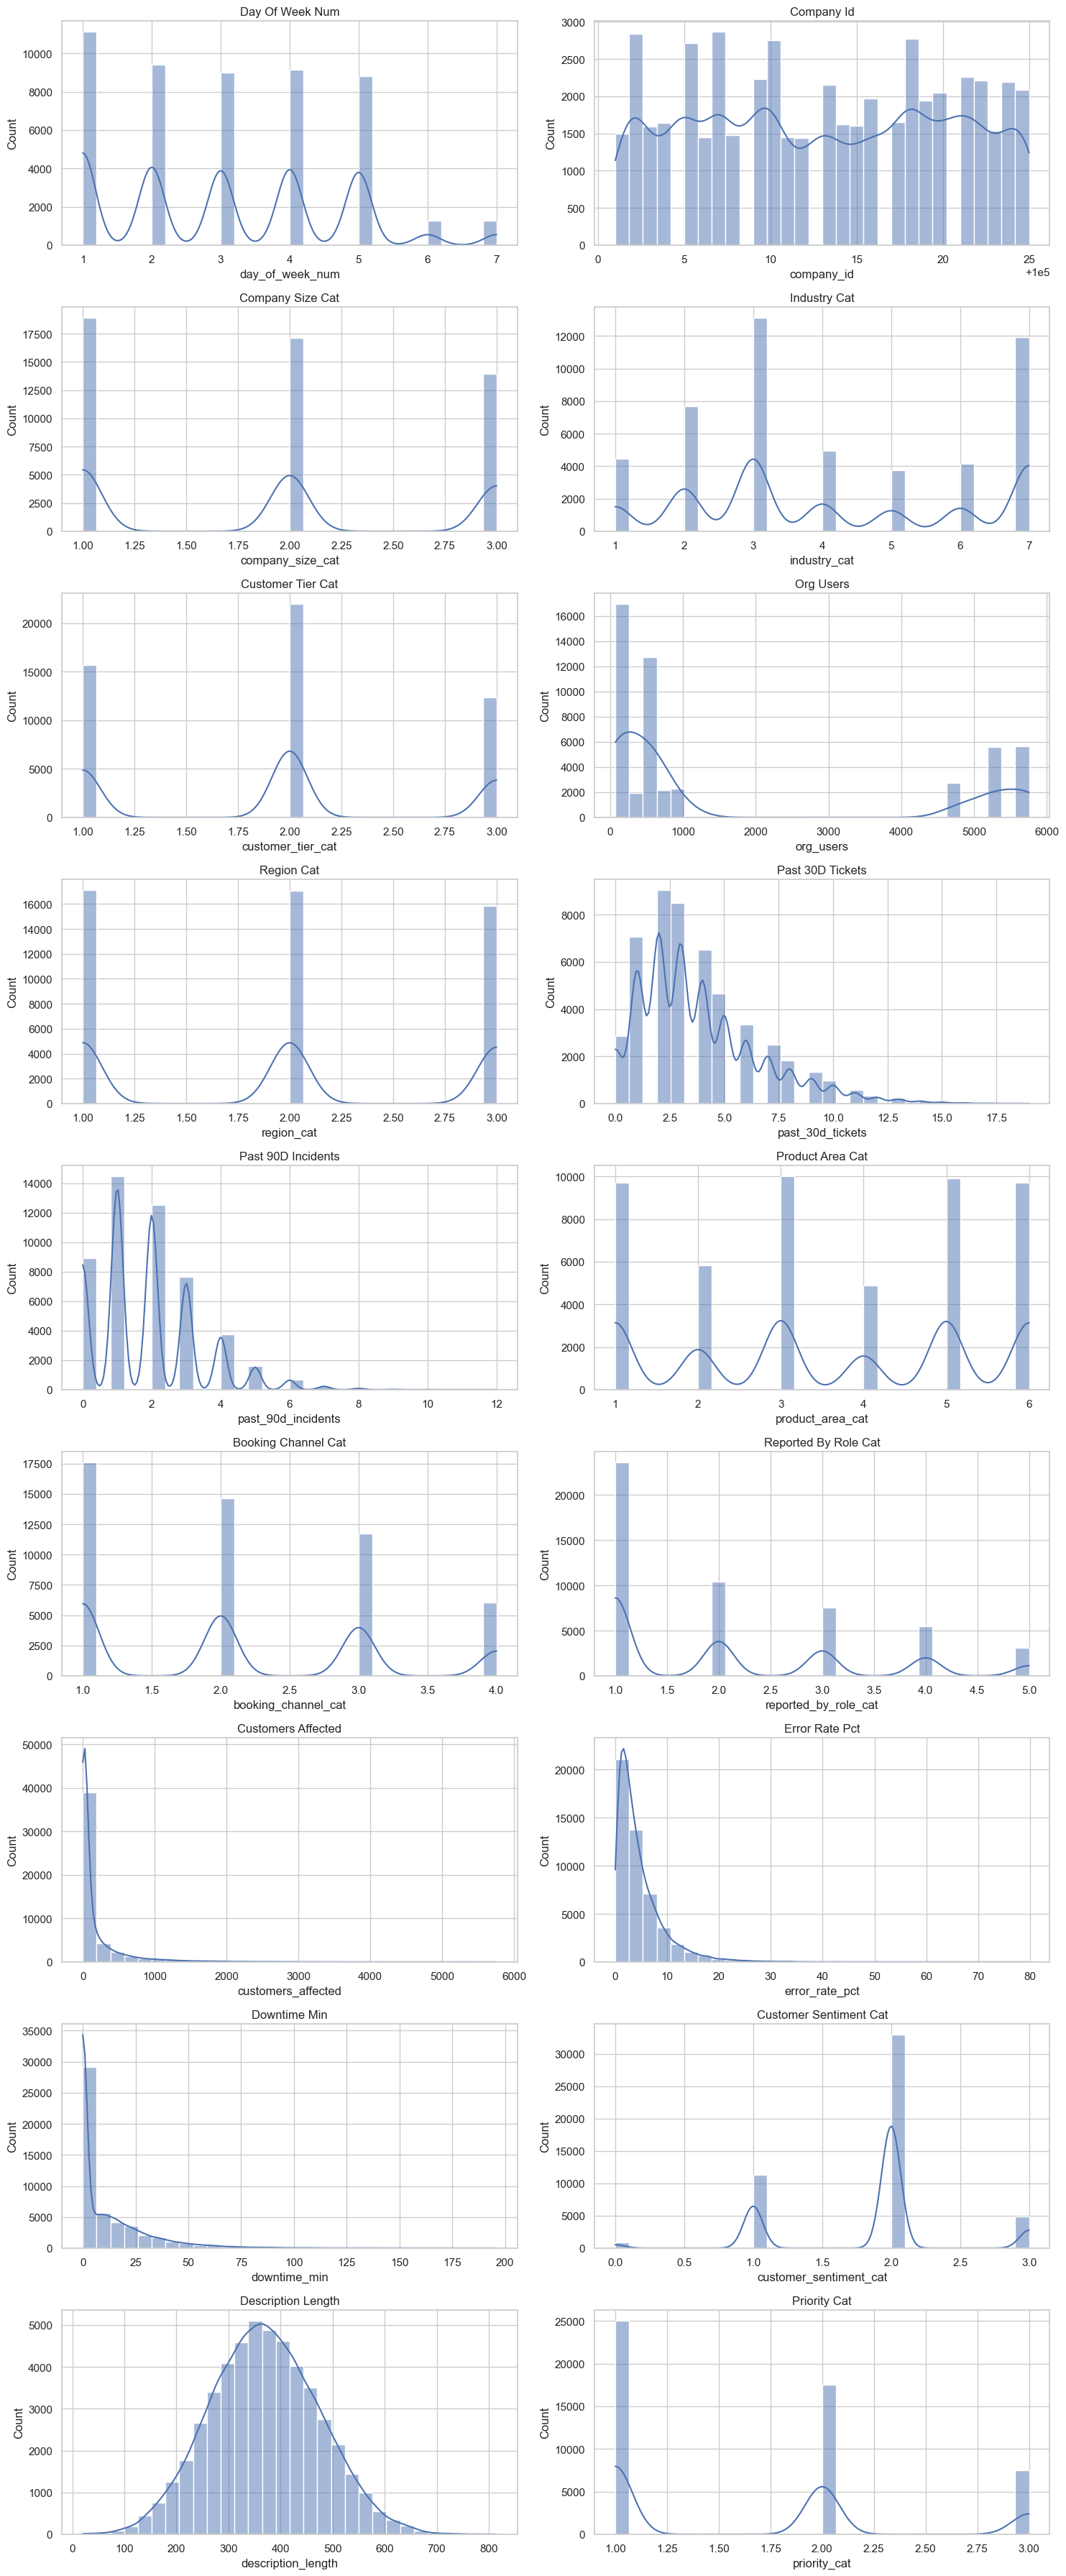

In [19]:
#Histogram of Numerical Features
import math

n = len(continuous_features)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(continuous_features):

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(column.replace("_"," ").title())

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

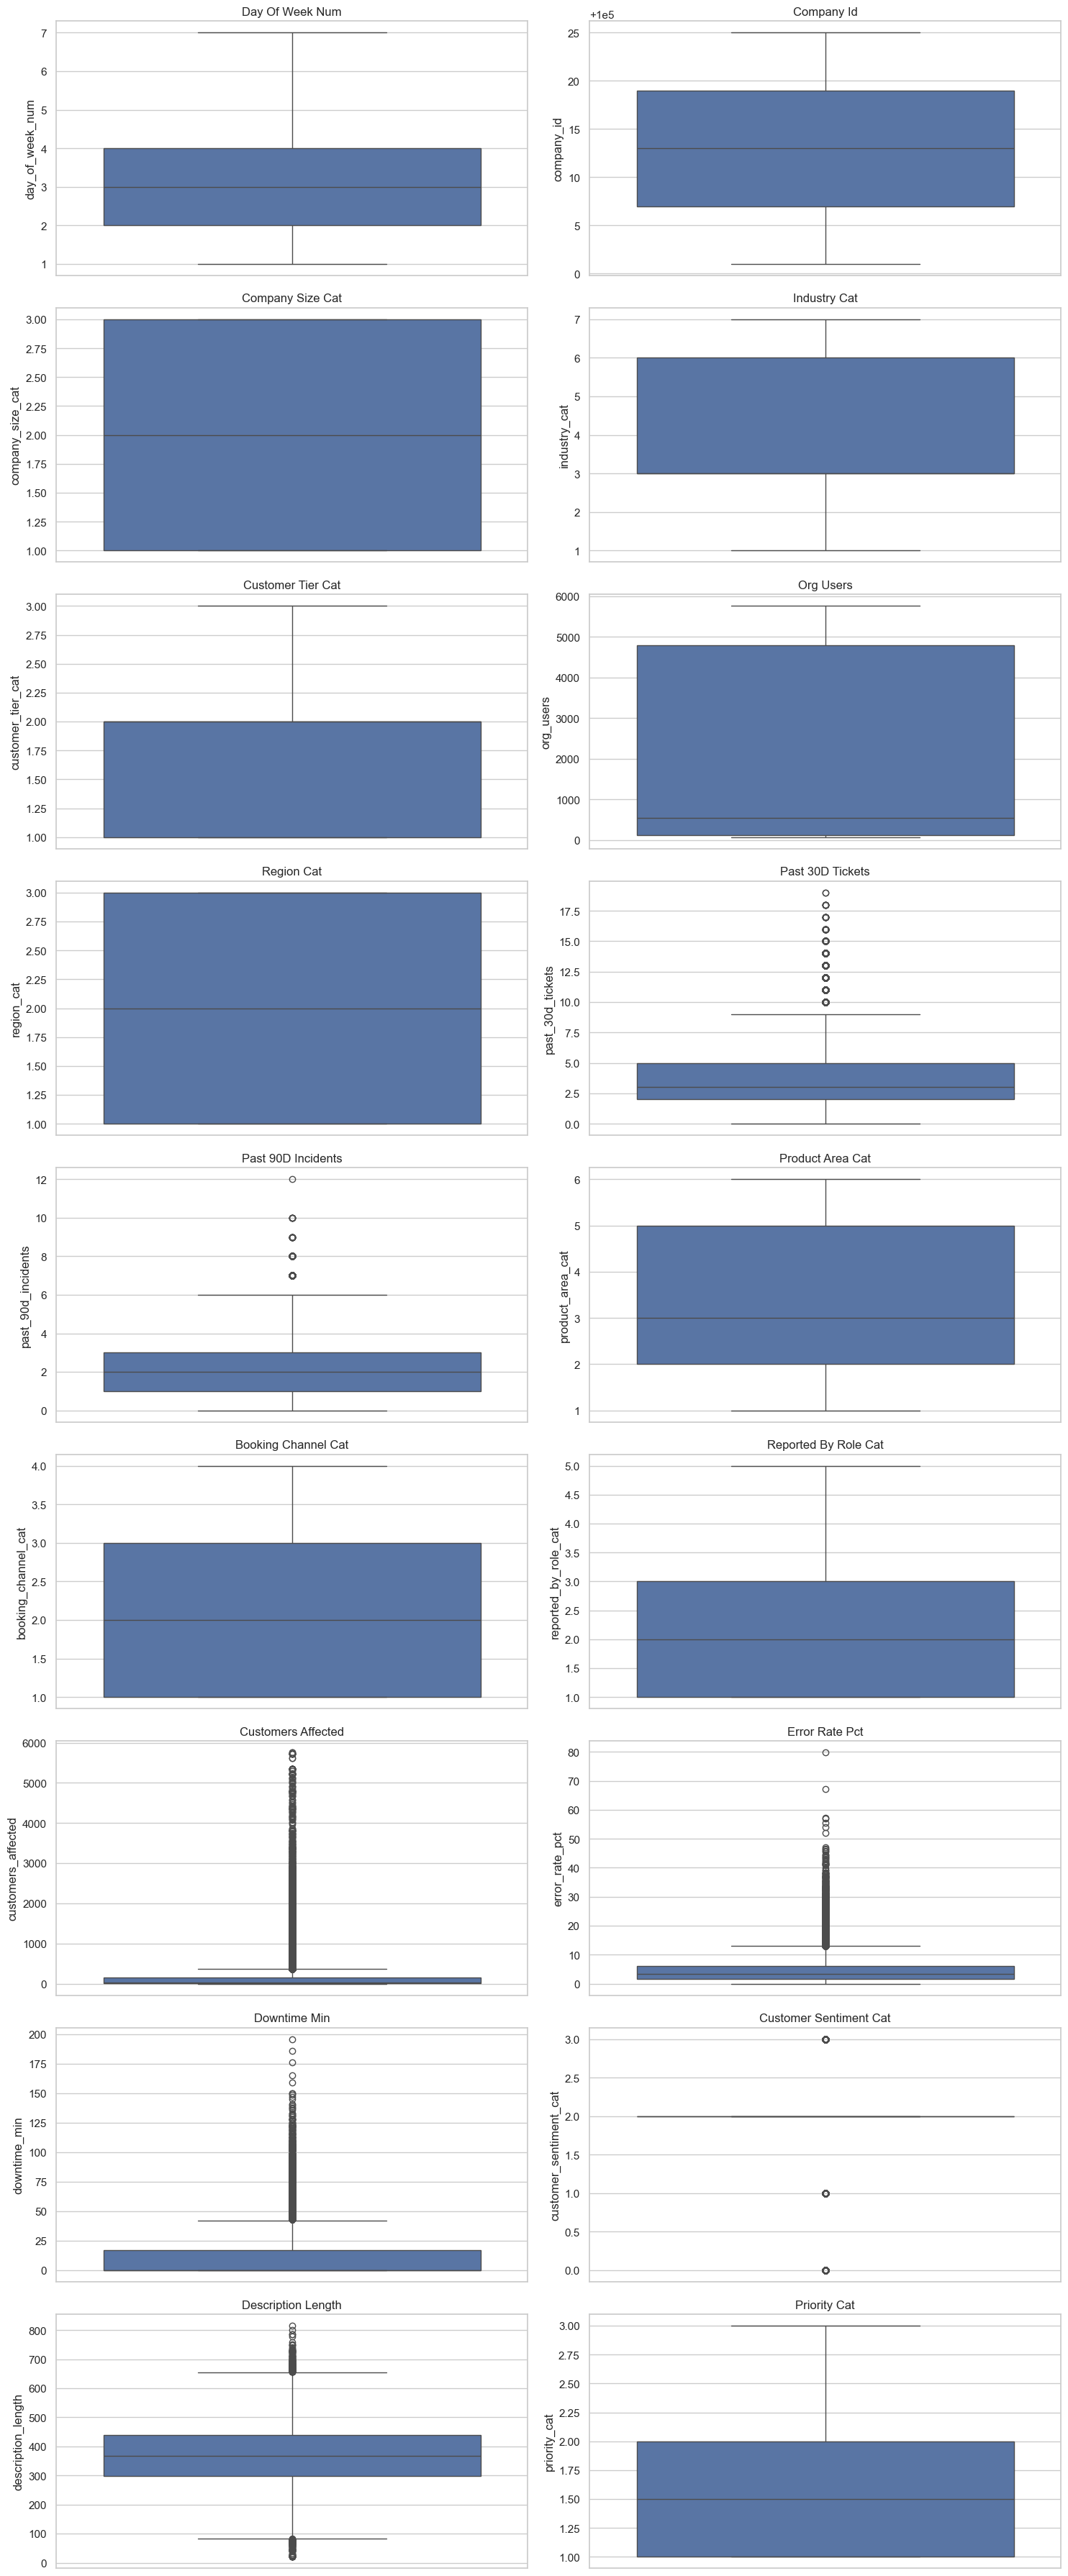

In [20]:
#Boxplot Visualization

import math

n = len(continuous_features)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(continuous_features):

    sns.boxplot(
        data=df,
        y=column,
        ax=axes[i]
    )

    axes[i].set_title(column.replace("_"," ").title())

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


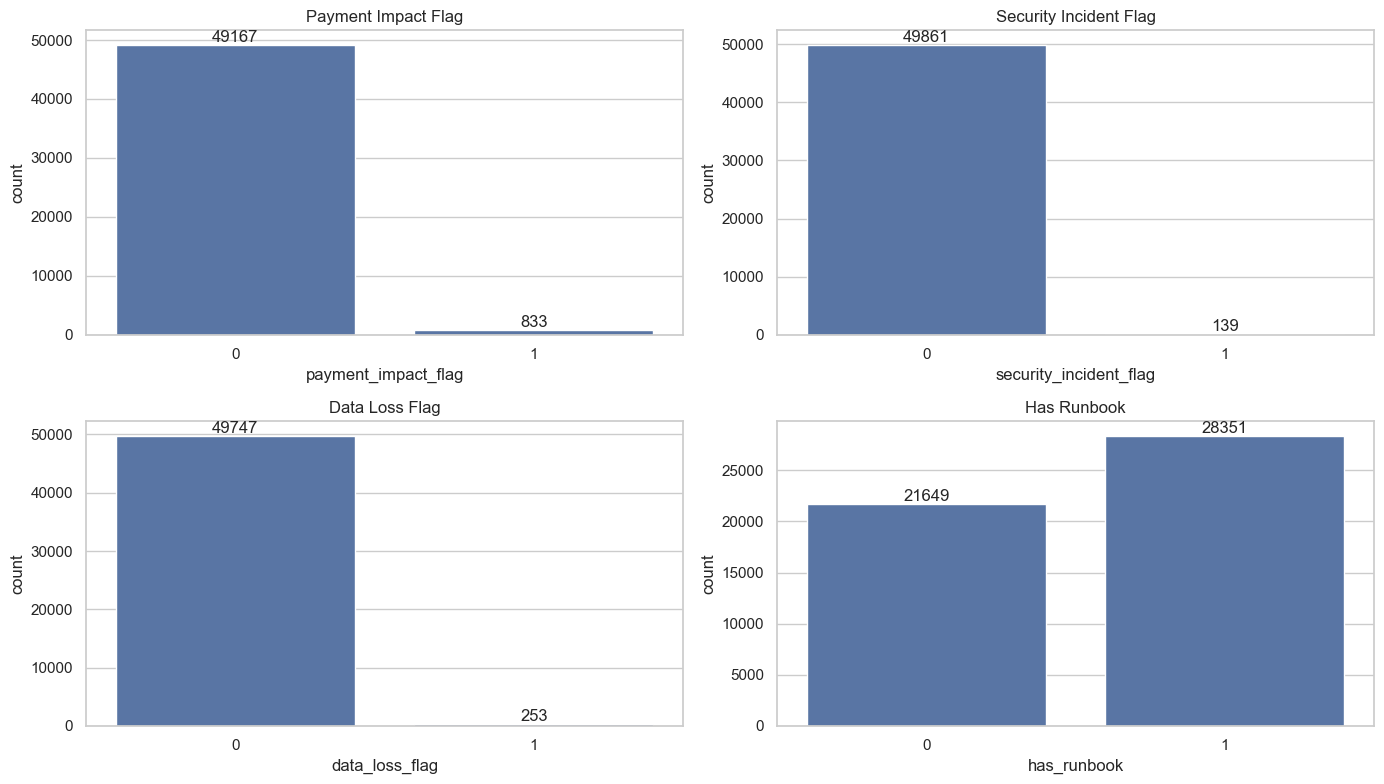

In [21]:
#Binary Variables

import math

n = len(binary_features)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(binary_features):

    sns.countplot(
        data=df,
        x=column,
        ax=axes[i]
    )

    axes[i].set_title(column.replace("_"," ").title())

    for container in axes[i].containers:
        axes[i].bar_label(container)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

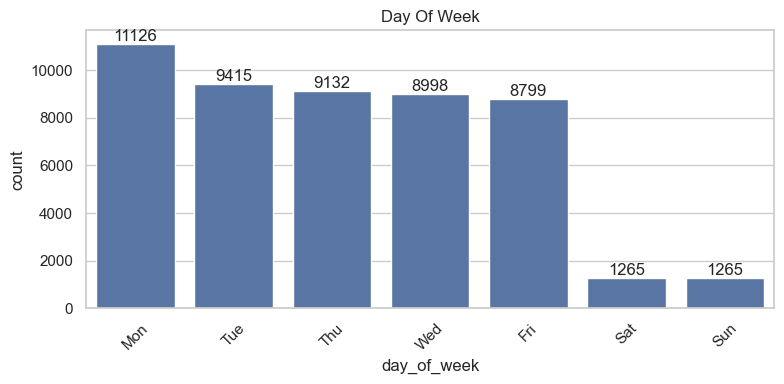

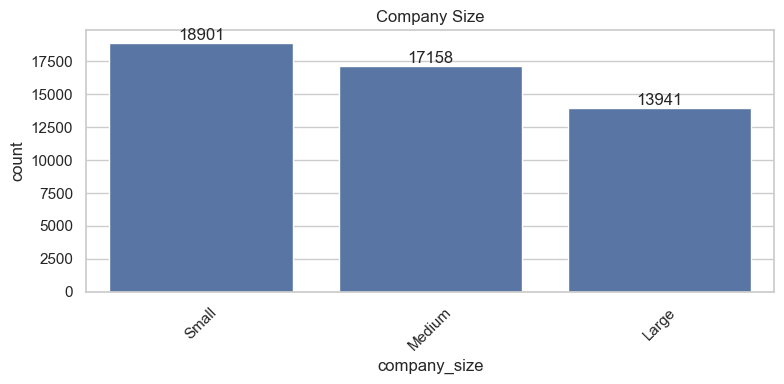

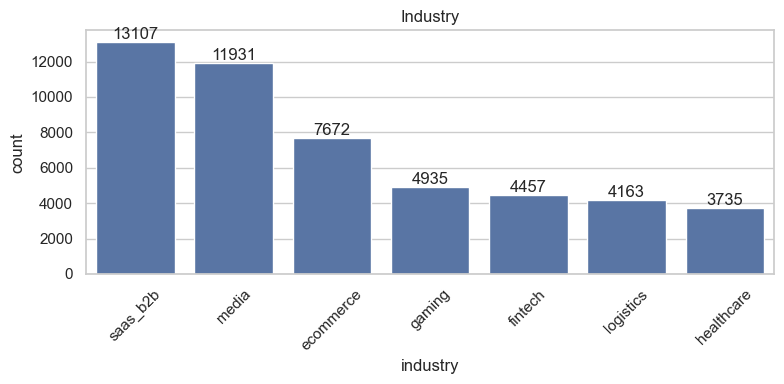

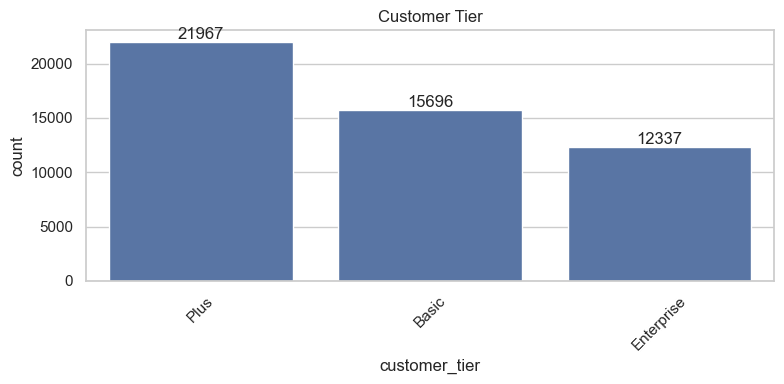

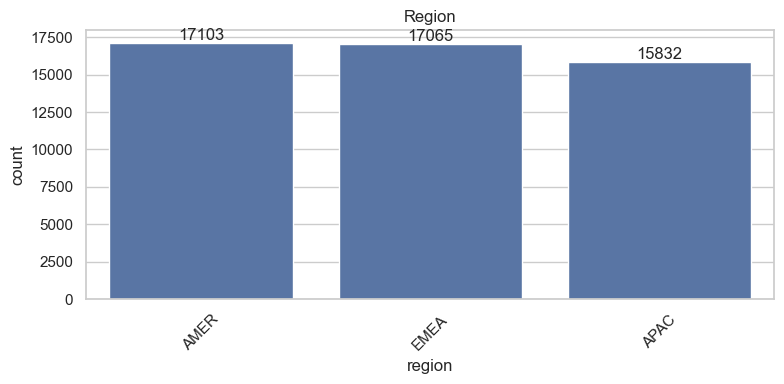

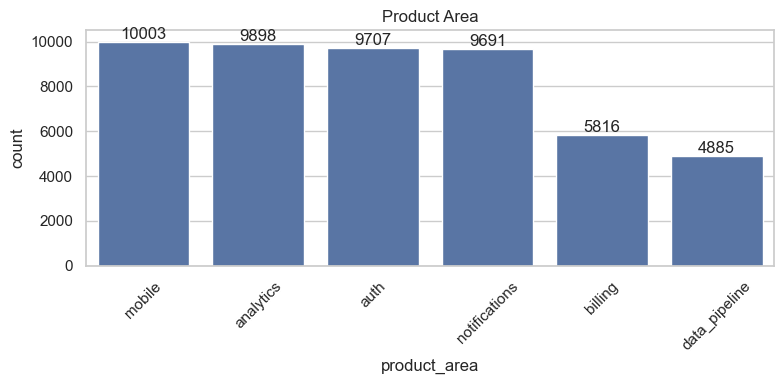

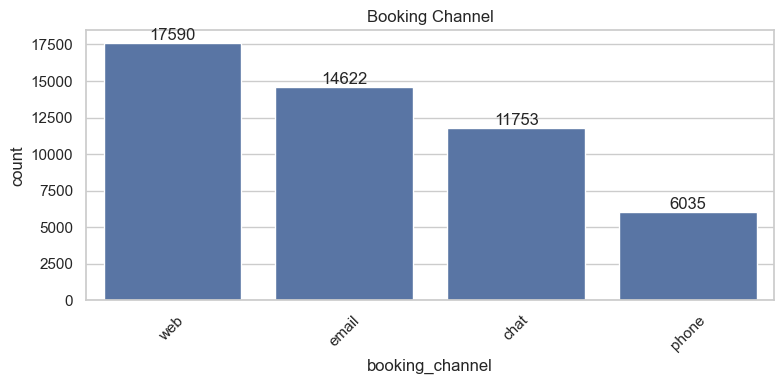

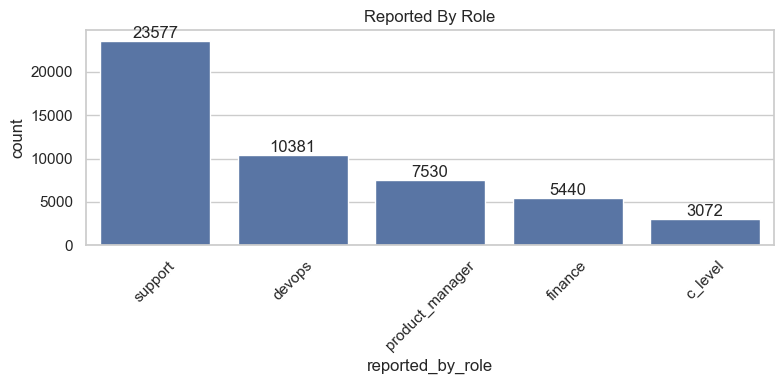

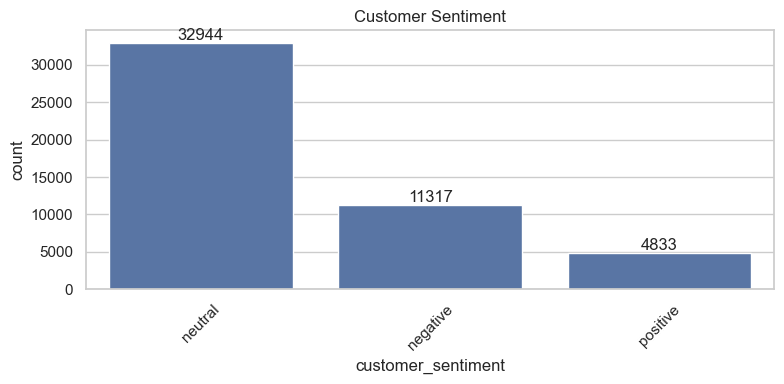

In [22]:
#Categoorical Variables

for column in categorical_features:

    plt.figure(figsize=(8,4))

    order = df[column].value_counts().index

    ax = sns.countplot(
        data=df,
        x=column,
        order=order
    )

    plt.xticks(rotation=45)

    plt.title(column.replace("_"," ").title())

    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()

    plt.show()

In [23]:
#Feature Summary

feature_summary = pd.DataFrame({
    "Feature Type": ["Continuous", "Binary", "Categorical"],
    "Count": [
        len(continuous_features),
        len(binary_features),
        len(categorical_features)
    ]
})

feature_summary

,Feature Type,Count
0,Continuous,18
1,Binary,4
2,Categorical,9


# 4. Bivariate Analysis

This section explores the relationship between the predictor variables and the target variable (`priority`). The objective is to identify patterns that may explain ticket severity and determine which features are likely to contribute to the predictive model.

## 4.1 Continuous Features vs Target

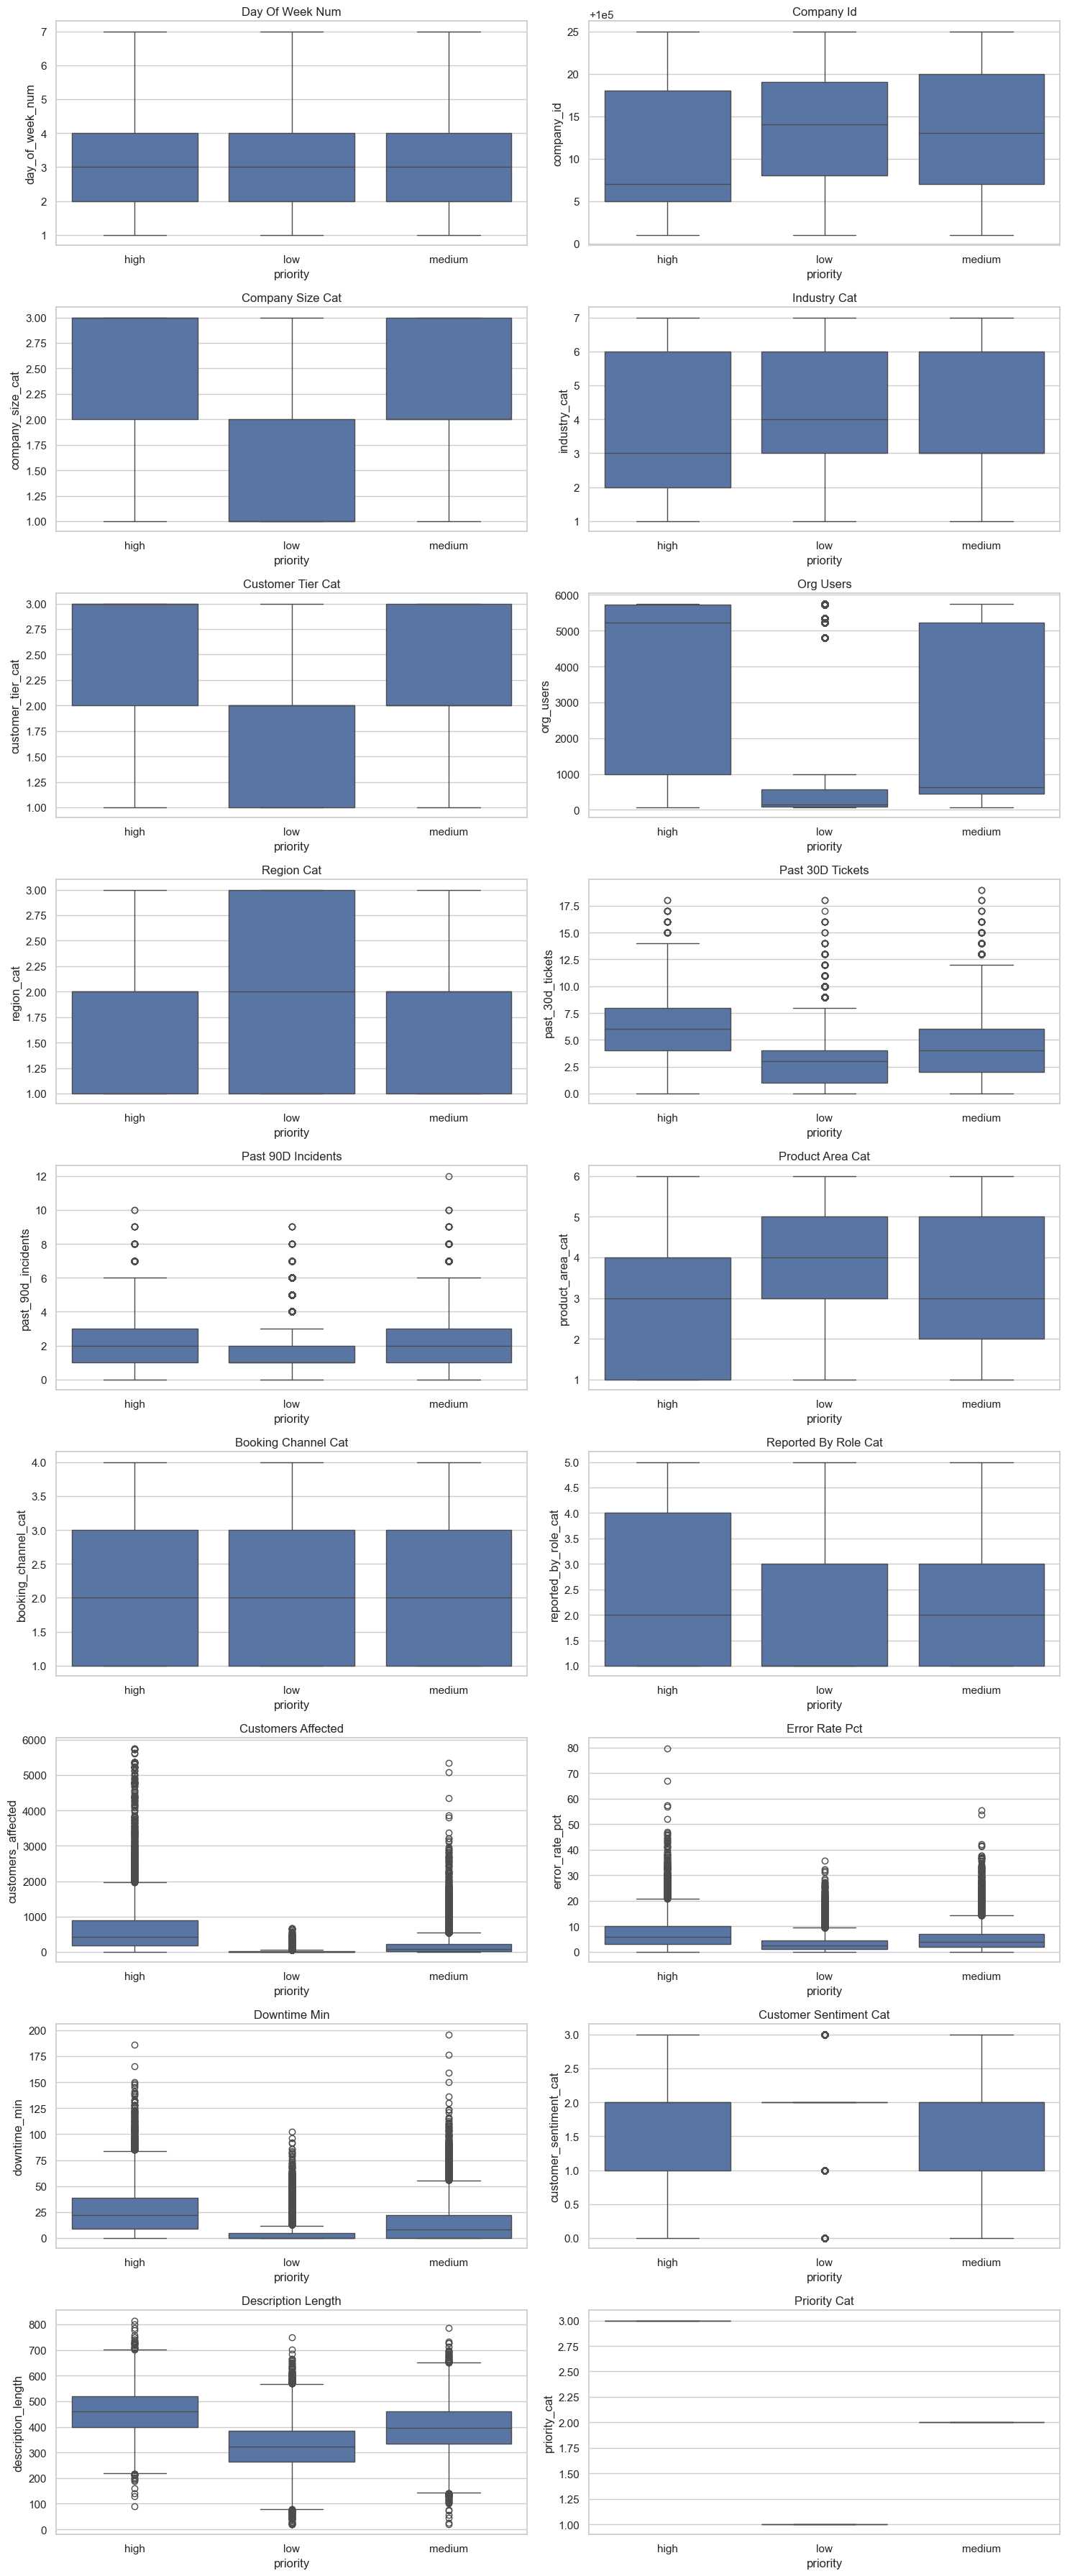

In [24]:
import math

n = len(continuous_features)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(continuous_features):

    sns.boxplot(
        data=df,
        x=target_column,
        y=column,
        order=sorted(df[target_column].unique()),
        ax=axes[i]
    )

    axes[i].set_title(column.replace("_", " ").title())

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [25]:
#Mean Values
continuous_summary = (
    df
    .groupby(target_column)[continuous_features]
    .mean()
    .round(2)
)

continuous_summary

,day_of_week_num,company_id,company_size_cat,industry_cat,customer_tier_cat,org_users,region_cat,past_30d_tickets,past_90d_incidents,product_area_cat,booking_channel_cat,reported_by_role_cat,customers_affected,error_rate_pct,downtime_min,customer_sentiment_cat,description_length,priority_cat
priority,,,,,,,,,,,,,,,,,,
high,3.06,100010.55,2.71,3.95,2.51,4129.60,1.64,5.85,2.40,2.97,2.41,2.42,693.69,7.67,26.99,1.75,459.63,3.00
low,3.08,100013.40,1.47,4.22,1.63,648.73,2.16,2.87,1.58,3.86,1.98,1.91,24.15,3.38,4.49,1.87,324.37,1.00
medium,3.08,100013.59,2.17,4.05,2.12,2337.82,1.86,4.30,1.99,3.41,2.22,2.19,191.00,5.13,13.78,1.81,396.19,2.00


In [26]:
#Median Values
continuous_median = (
    df
    .groupby(target_column)[continuous_features]
    .median()
    .round(2)
)

continuous_median

,day_of_week_num,company_id,company_size_cat,industry_cat,customer_tier_cat,org_users,region_cat,past_30d_tickets,past_90d_incidents,product_area_cat,booking_channel_cat,reported_by_role_cat,customers_affected,error_rate_pct,downtime_min,customer_sentiment_cat,description_length,priority_cat
priority,,,,,,,,,,,,,,,,,,
high,3.00,100007.00,3.00,3.00,3.00,5223.00,2.00,6.00,2.00,3.00,2.00,2.00,429.50,5.86,22.00,2.00,460.00,3.00
low,3.00,100014.00,1.00,4.00,2.00,150.00,2.00,3.00,1.00,4.00,2.00,1.00,9.00,2.46,0.00,2.00,324.00,1.00
medium,3.00,100013.00,2.00,3.00,2.00,639.00,2.00,4.00,2.00,3.00,2.00,2.00,76.00,3.80,8.00,2.00,395.00,2.00


### Observations

Compare how each continuous feature changes across ticket priorities.

Look for variables that show a clear increasing or decreasing trend, as these are likely to be informative predictors during model training.

## 4.2 Binary Features vs Target

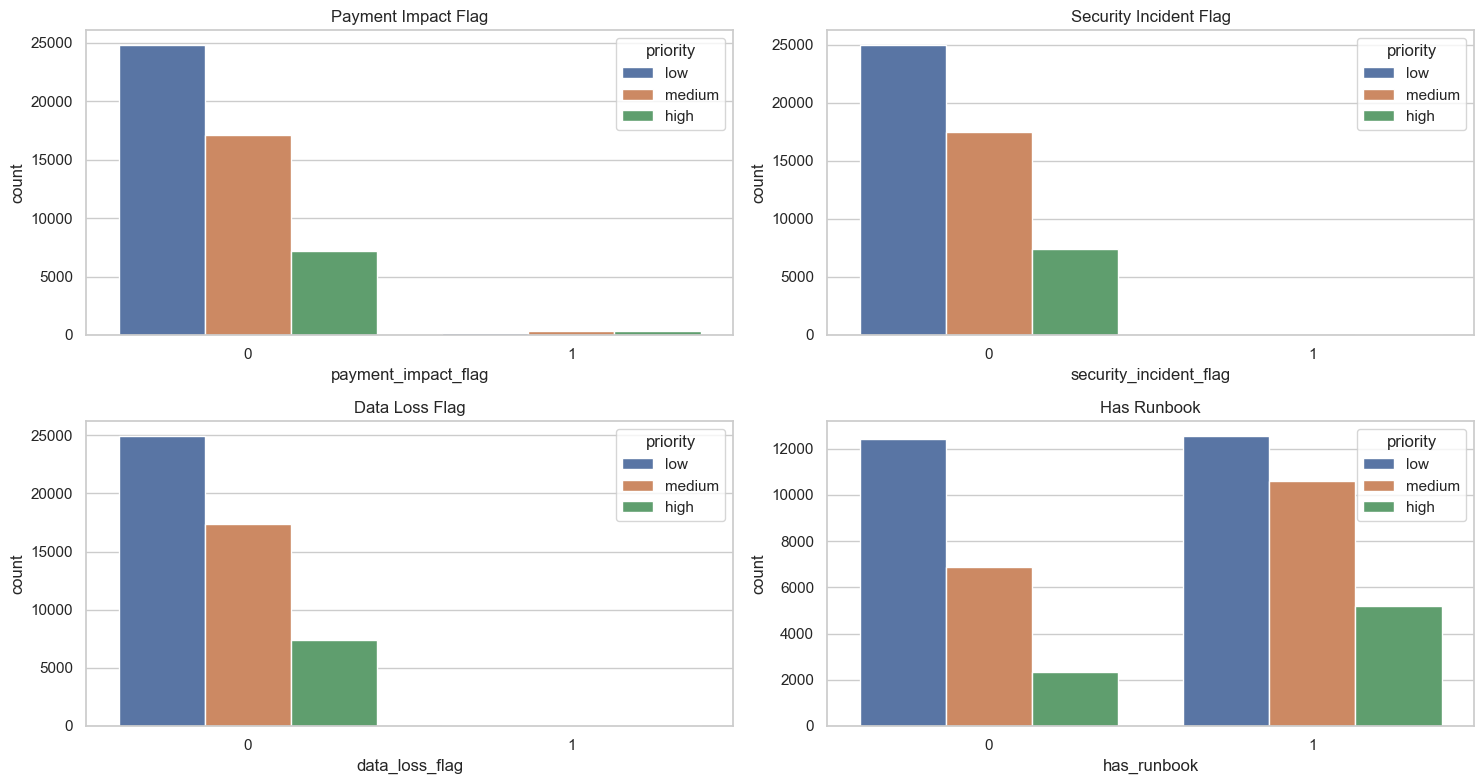

In [27]:
import math

n = len(binary_features)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(binary_features):

    sns.countplot(
        data=df,
        x=column,
        hue=target_column,
        ax=axes[i]
    )

    axes[i].set_title(column.replace("_"," ").title())

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

In [28]:
#Cross Tabulation of Binary Features with Target Variable

for column in binary_features:

    print("="*70)
    print(column)
    print("="*70)

    display(
        pd.crosstab(
            df[column],
            df[target_column],
            normalize="index"
        ).round(3)
    )

payment_impact_flag


priority,high,low,medium
payment_impact_flag,,,
0,0.15,0.51,0.35
1,0.36,0.21,0.42


security_incident_flag


priority,high,low,medium
security_incident_flag,,,
0,0.15,0.50,0.35
1,0.61,0.11,0.28


data_loss_flag


priority,high,low,medium
data_loss_flag,,,
0,0.15,0.50,0.35
1,0.42,0.23,0.36


has_runbook


priority,high,low,medium
has_runbook,,,
0,0.11,0.57,0.32
1,0.18,0.44,0.37


### Observations

Binary variables allow us to evaluate whether specific operational conditions, such as payment impact or security incidents, are associated with higher ticket priorities.

## 4.3 Categorical Features vs Target

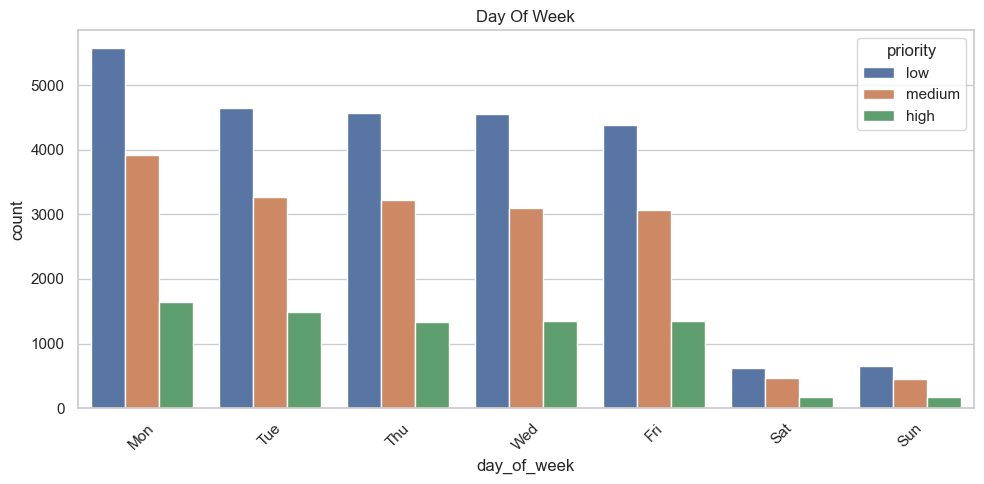

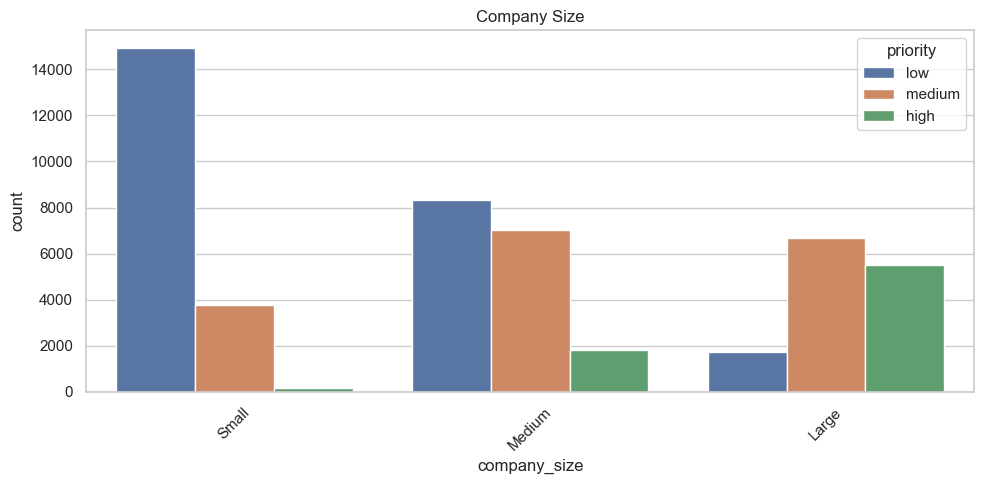

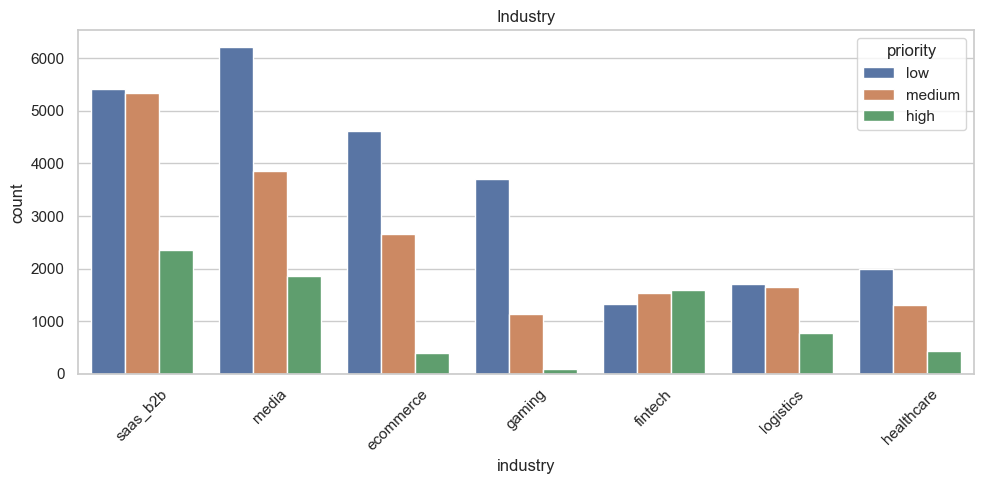

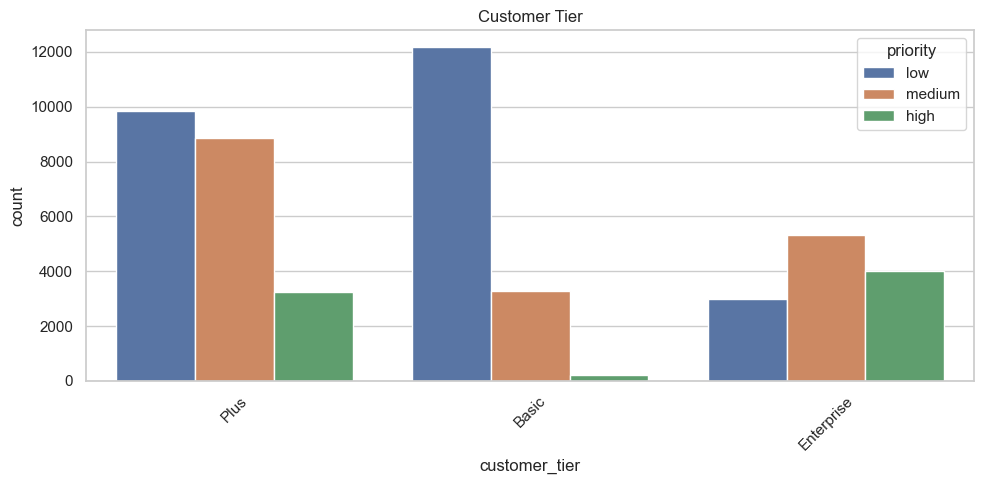

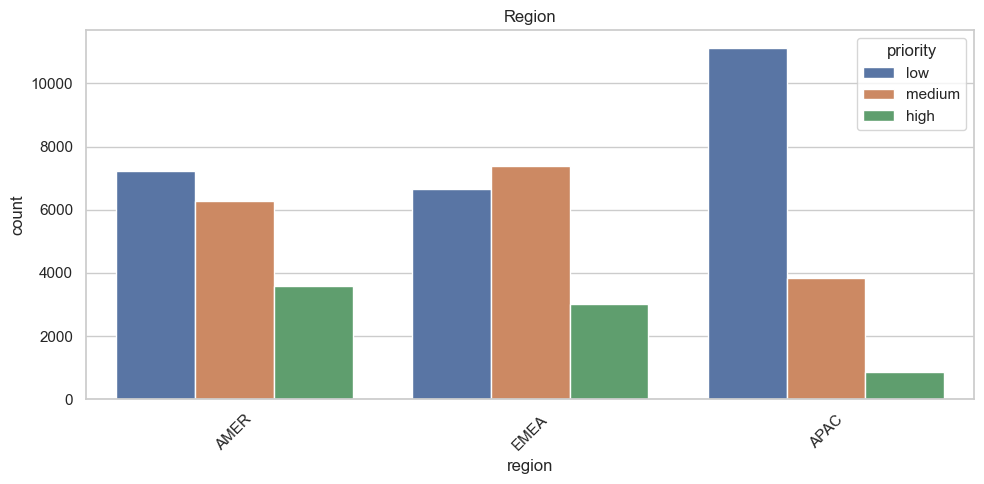

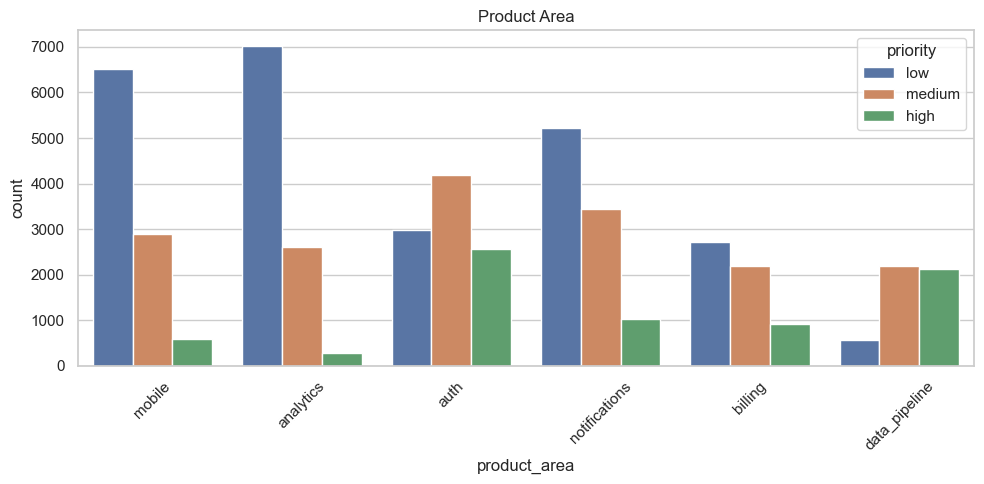

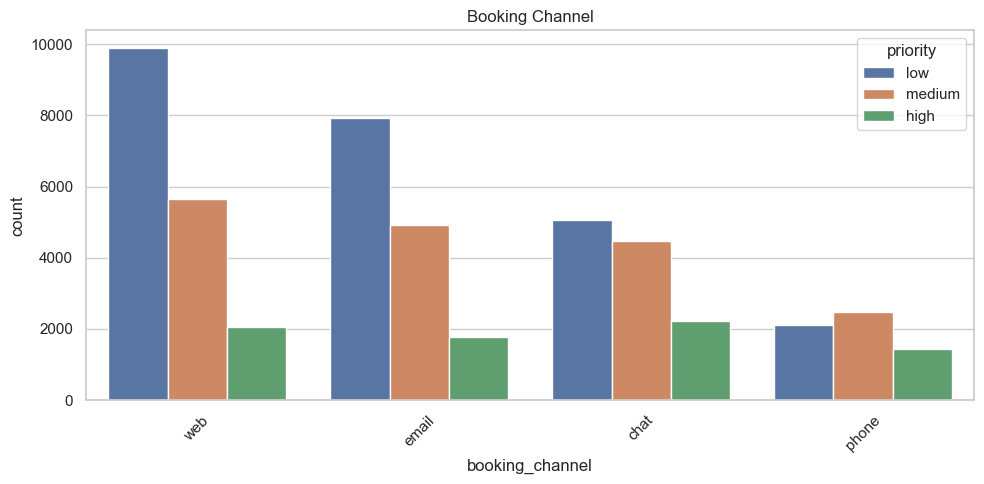

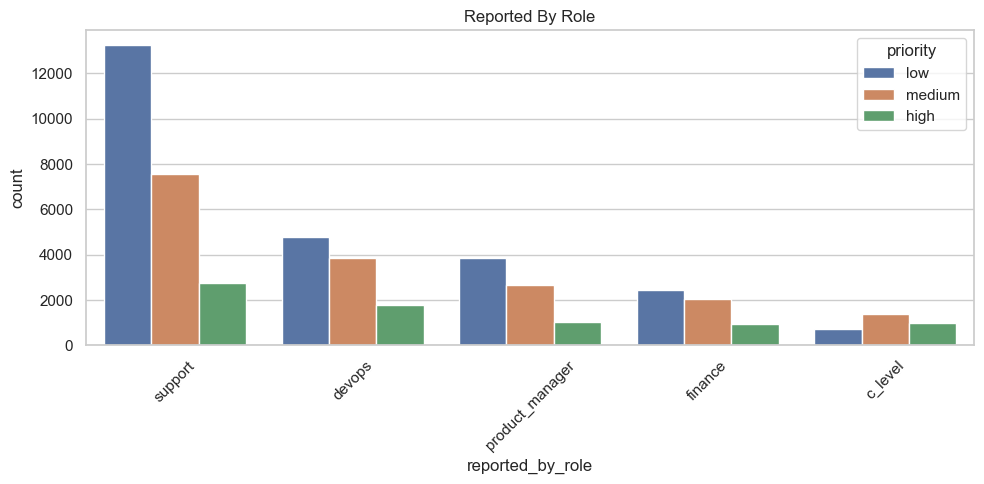

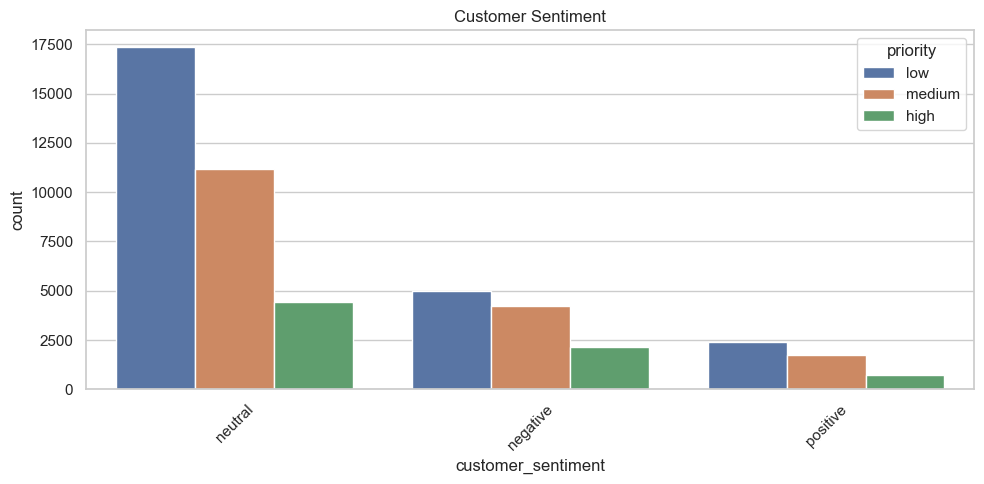

In [29]:
for column in categorical_features:

    plt.figure(figsize=(10,5))

    order = df[column].value_counts().index

    sns.countplot(
        data=df,
        x=column,
        hue=target_column,
        order=order
    )

    plt.xticks(rotation=45)

    plt.title(column.replace("_"," ").title())

    plt.tight_layout()

    plt.show()

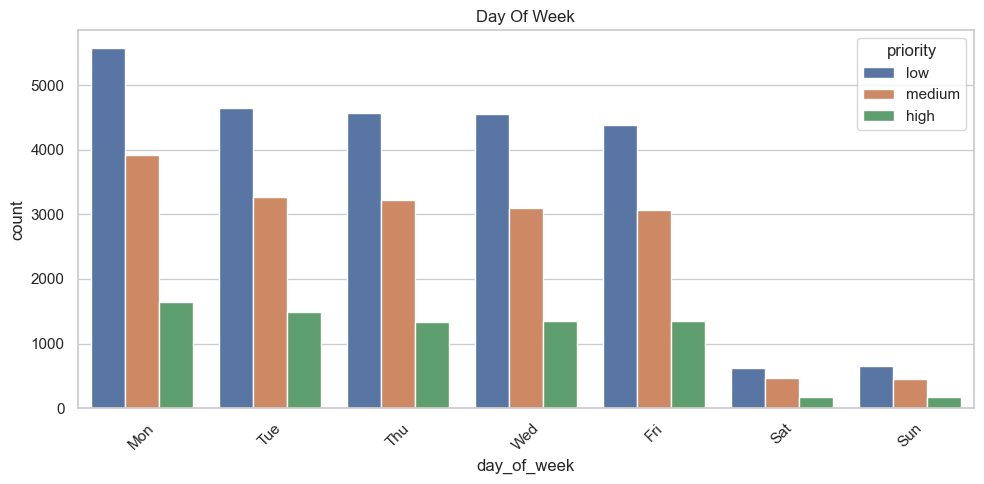

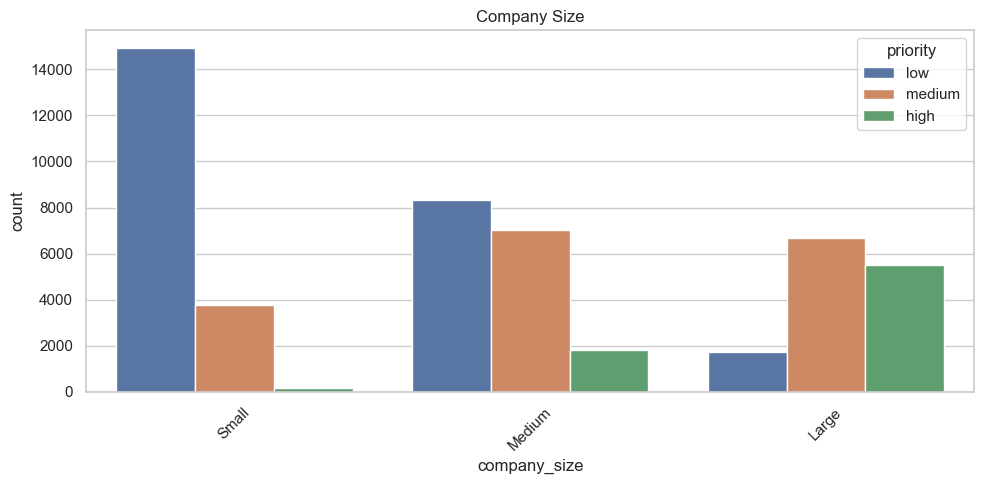

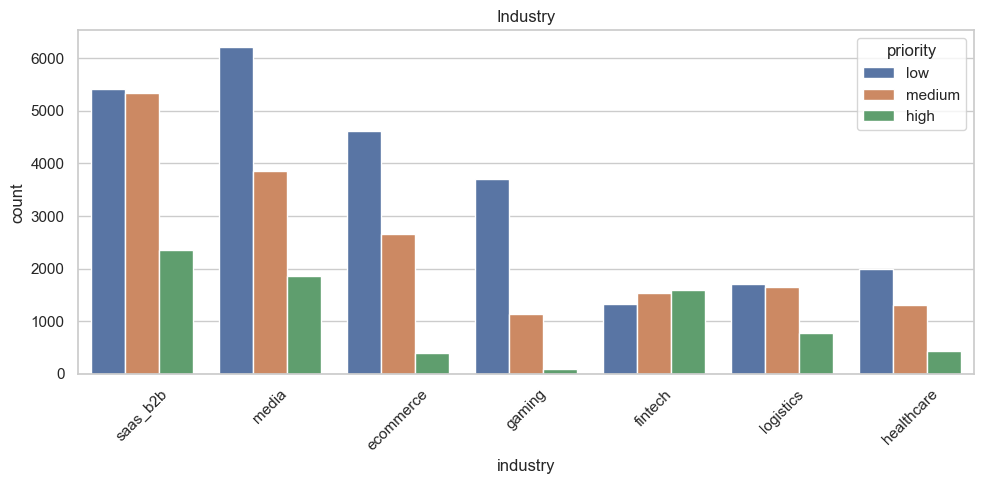

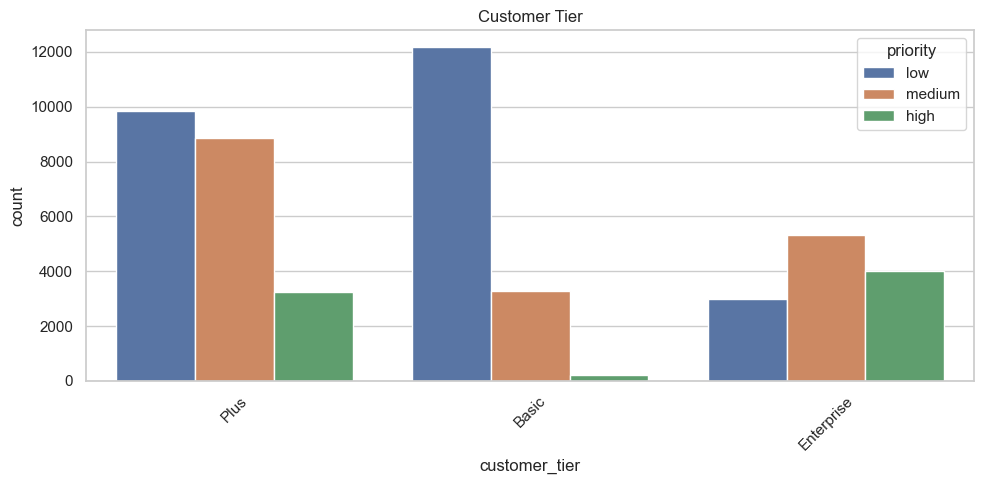

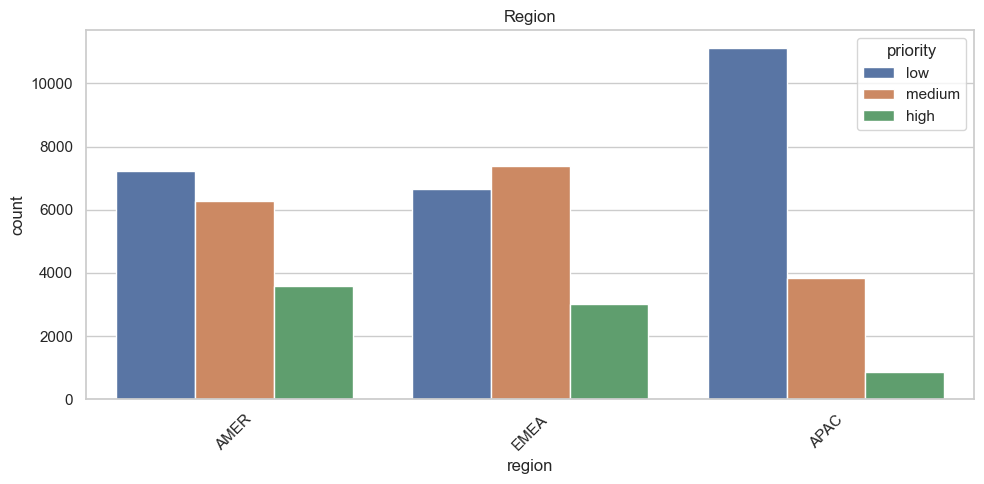

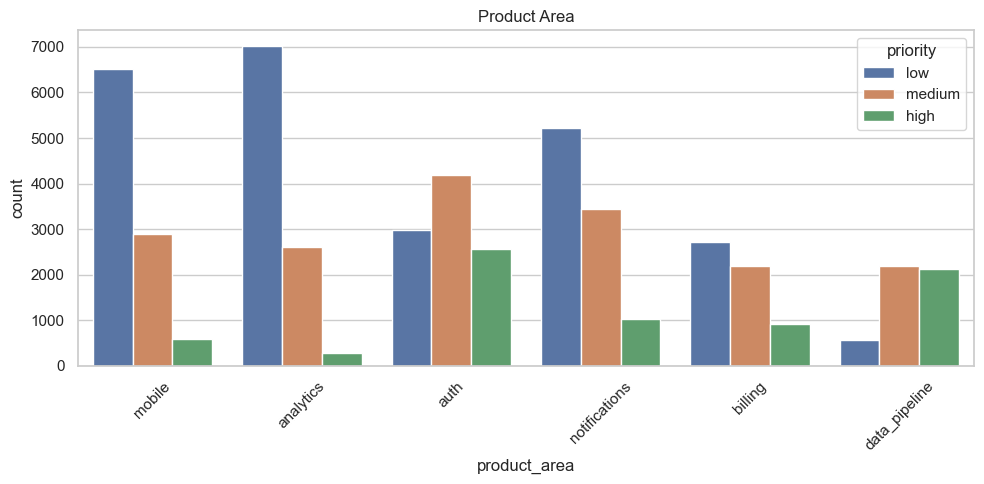

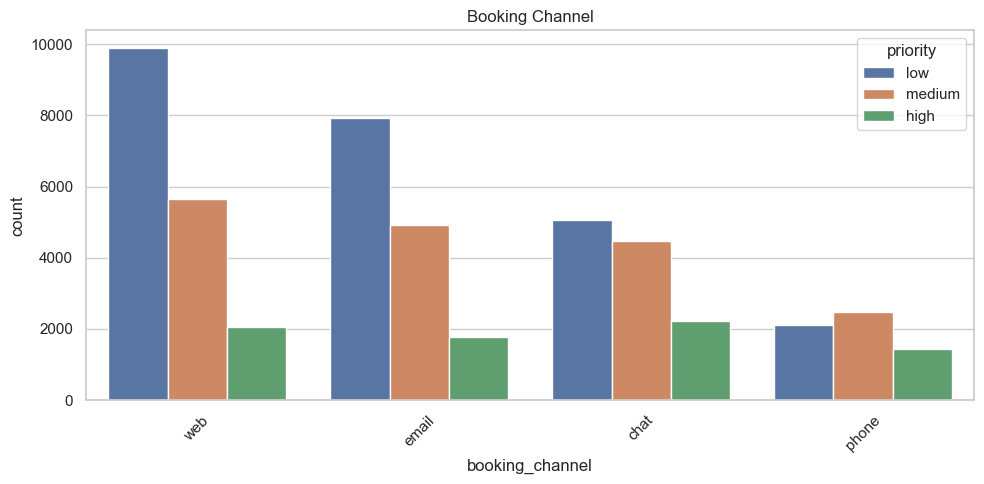

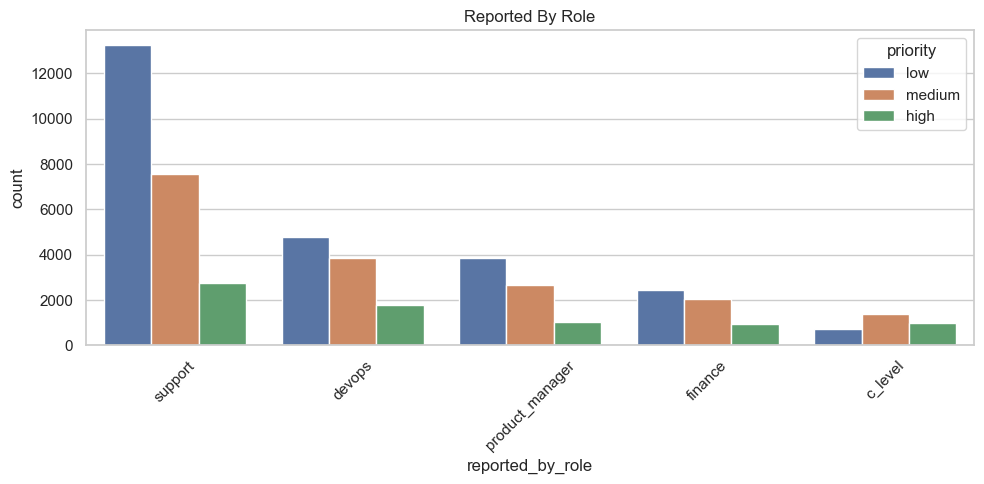

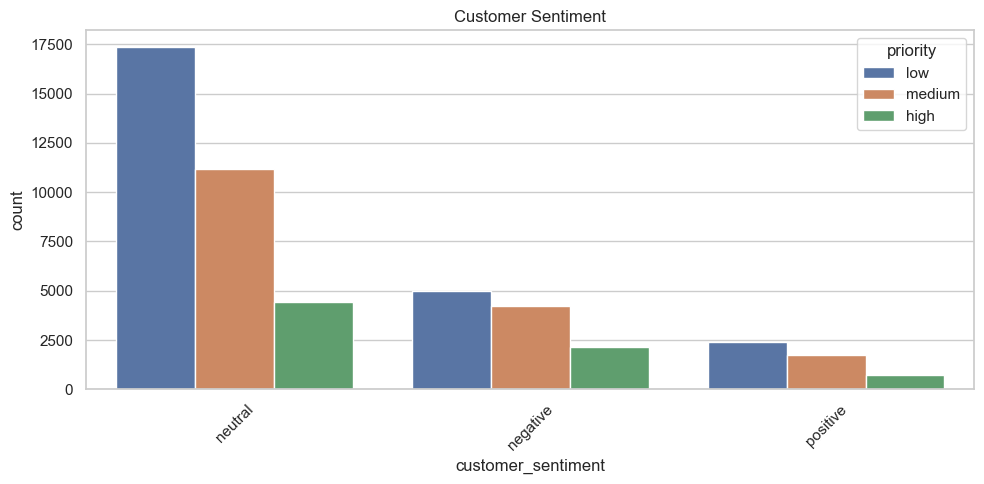

In [30]:
for column in categorical_features:

    plt.figure(figsize=(10,5))

    order = df[column].value_counts().index

    sns.countplot(
        data=df,
        x=column,
        hue=target_column,
        order=order
    )

    plt.xticks(rotation=45)

    plt.title(column.replace("_"," ").title())

    plt.tight_layout()

    plt.show()

### Observations

Categorical variables help identify whether certain customer segments, industries, regions, or reporting channels are associated with specific ticket priorities.


### 4.4 Feature Relationship Summary

In [31]:
feature_relationship = (
    df
    .groupby(target_column)[continuous_features]
    .agg(["mean","median"])
    .round(2)
)

feature_relationship

day_of_week_num        company_id           company_size_cat         \
                    mean median       mean    median             mean median   
priority                                                                       
high                3.06   3.00  100010.55 100007.00             2.71   3.00   
low                 3.08   3.00  100013.40 100014.00             1.47   1.00   
medium              3.08   3.00  100013.59 100013.00             2.17   2.00   

         industry_cat        customer_tier_cat        org_users          \
                 mean median              mean median      mean  median   
priority                                                                  
high             3.95   3.00              2.51   3.00   4129.60 5223.00   
low              4.22   4.00              1.63   2.00    648.73  150.00   
medium           4.05   3.00              2.12   2.00   2337.82  639.00   

         region_cat        past_30d_tickets        past_90d_incidents         \
               mean median             mean median               mean median   
priority                                                                       
high           1.64   2.00             5.85   6.00               2.40   2.00   
low            2.16   2.00             2.87   3.00               1.58   1.00   
medium         1.86   2.00             4.30   4.00               1.99   2.00   

         product_area_cat        booking_channel_cat         \
                     mean median                mean median   
priority                                                      
high                 2.97   3.00                2.41   2.00   
low                  3.86   4.00                1.98   2.00   
medium               3.41   3.00                2.22   2.00   

         reported_by_role_cat        customers_affected        error_rate_pct  \
                         mean median               mean median           mean   
priority                                                                        
high                     2.42   2.00             693.69 429.50           7.67   
low                      1.91   1.00              24.15   9.00           3.38   
medium                   2.19   2.00             191.00  76.00           5.13   

                downtime_min        customer_sentiment_cat         \
         median         mean median                   mean median   
priority                                                            
high       5.86        26.99  22.00                   1.75   2.00   
low        2.46         4.49   0.00                   1.87   2.00   
medium     3.80        13.78   8.00                   1.81   2.00   

         description_length        priority_cat         
                       mean median         mean median  
priority                                                
high                 459.63 460.00         3.00   3.00  
low                  324.37 324.00         1.00   1.00  
medium               396.19 395.00         2.00   2.00

### Summary

The previous analyses highlight how feature distributions vary across priority levels. Variables that exhibit clear separation between classes may provide strong predictive power during the modeling stage.

# 5. Correlation Analysis

Correlation analysis helps identify linear relationships between numerical variables. Understanding these relationships is useful for detecting multicollinearity, identifying redundant features, and exploring potential predictors of ticket priority.

In [34]:
#Correlation Matrix
correlation_matrix = df[continuous_features].corr()

correlation_matrix

,day_of_week_num,company_id,company_size_cat,industry_cat,customer_tier_cat,org_users,region_cat,past_30d_tickets,past_90d_incidents,product_area_cat,booking_channel_cat,reported_by_role_cat,customers_affected,error_rate_pct,downtime_min,customer_sentiment_cat,description_length,priority_cat
day_of_week_num,1.00,-0.00,0.00,0.00,-0.00,0.00,-0.01,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00
company_id,-0.00,1.00,-0.11,-0.20,-0.02,-0.33,-0.05,-0.22,-0.11,-0.01,-0.04,0.02,-0.18,0.02,0.01,-0.00,-0.05,-0.10
company_size_cat,0.00,-0.11,1.00,-0.03,0.64,0.89,-0.37,0.61,0.32,0.03,0.27,0.12,0.50,0.05,0.03,-0.08,0.51,0.58
industry_cat,0.00,-0.20,-0.03,1.00,0.09,-0.04,-0.02,-0.02,0.00,0.09,-0.00,-0.01,-0.05,-0.00,-0.01,0.01,-0.05,-0.05
customer_tier_cat,-0.00,-0.02,0.64,0.09,1.00,0.46,-0.36,0.37,0.23,0.02,0.17,0.08,0.25,0.03,0.02,-0.06,0.33,0.44
org_users,0.00,-0.33,0.89,-0.04,0.46,1.00,-0.41,0.67,0.33,0.02,0.26,0.09,0.56,0.04,0.02,-0.08,0.48,0.55
region_cat,-0.01,-0.05,-0.37,-0.02,-0.36,-0.41,1.00,-0.28,-0.14,0.01,-0.16,-0.04,-0.23,-0.02,-0.02,0.05,-0.21,-0.24
past_30d_tickets,-0.00,-0.22,0.61,-0.02,0.37,0.67,-0.28,1.00,0.24,0.00,0.18,0.07,0.37,0.03,0.01,-0.05,0.32,0.39
past_90d_incidents,-0.00,-0.11,0.32,0.00,0.23,0.33,-0.14,0.24,1.00,-0.00,0.10,0.04,0.19,0.01,0.00,-0.03,0.16,0.20
product_area_cat,0.00,-0.01,0.03,0.09,0.02,0.02,0.01,0.00,-0.00,1.00,0.01,0.00,-0.11,-0.09,-0.07,0.01,-0.09,-0.18


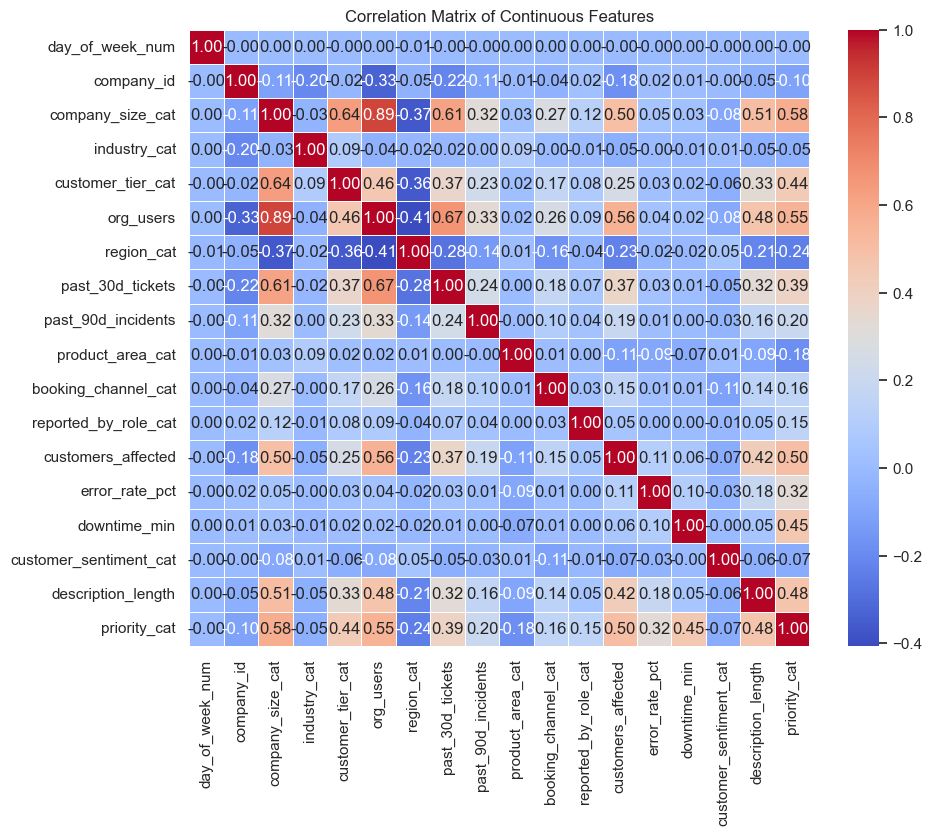

In [35]:
#Heatmap of Correlation Matrix

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Continuous Features")

plt.show()

In [36]:
#Strongest Correlations

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

corr_pairs = (
    corr_pairs
    .sort_values(
        by="Correlation",
        key=abs,
        ascending=False
    )
)

corr_pairs.head(10)

,Feature 1,Feature 2,Correlation
41,company_size_cat,org_users,0.89
97,org_users,past_30d_tickets,0.67
40,company_size_cat,customer_tier_cat,0.64
43,company_size_cat,past_30d_tickets,0.61
53,company_size_cat,priority_cat,0.58
102,org_users,customers_affected,0.56
107,org_users,priority_cat,0.55
52,company_size_cat,description_length,0.51
233,customers_affected,priority_cat,0.50
48,company_size_cat,customers_affected,0.50


### Correlation Insights

- Strong positive correlations may indicate redundant information.
- Weak correlations suggest that variables contribute different information to the predictive model.
- No action will be taken at this stage; correlation findings will be considered during feature selection.

# 6. Data Quality Assessment

Before preparing the dataset for modeling, it is important to evaluate potential quality issues such as missing values, duplicate observations, outliers, and inconsistent data types.

In [40]:
#Missing Values Summary

missing_summary = (
    pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Percentage": (df.isnull().mean() * 100).round(2)
    })
    .query("`Missing Values` > 0")
    .sort_values("Missing Values", ascending=False)
)

missing_summary

,Missing Values,Percentage
customer_sentiment,906,1.81


## Observation

- Only 1 variable (customer_sentiment) presents a 1.81% of missing values, which suggests that the dataset has a high data quality.
- The treatment of these values will be defined during the preprocessing phase.


In [38]:
#Duplicate Rows

duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [39]:
#Outliers Detection (IQR)

outlier_summary = []

for column in continuous_features:

    Q1 = df[column].quantile(.25)
    Q3 = df[column].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()

    outlier_summary.append([
        column,
        outliers,
        round(outliers/len(df)*100,2)
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Outliers",
        "Percentage"
    ]
)

outlier_summary



,Feature,Outliers,Percentage
0,day_of_week_num,0,0.00
1,company_id,0,0.00
2,company_size_cat,0,0.00
3,industry_cat,0,0.00
4,customer_tier_cat,0,0.00
5,org_users,0,0.00
6,region_cat,0,0.00
7,past_30d_tickets,2352,4.70
8,past_90d_incidents,352,0.70
9,product_area_cat,0,0.00


### Data Quality Observations

Outliers detected through the IQR method are not necessarily errors. In operational datasets, extreme values may represent legitimate business events (e.g., major service outages or critical incidents). Decisions regarding their treatment will be made during preprocessing.

# 7. Key Business Insights

The exploratory analysis revealed several operational patterns that provide valuable insights into the factors associated with ticket priority. These findings will guide both the preprocessing stage and the development of the machine learning model.

### 1. Operational Impact Drives Ticket Priority

Tickets with longer service downtime and a greater number of affected customers consistently exhibit higher priority levels. These operational metrics appear to be among the strongest indicators of ticket severity.

---

### 2. Critical Events Are Associated with High-Priority Tickets

Binary operational indicators such as security incidents, payment impact, and other service disruption flags occur more frequently in high-priority tickets, suggesting that these events play an important role in prioritization.

---

### 3. Customer and Business Characteristics Influence Ticket Severity

Variables such as customer tier, company size, industry, and product area exhibit noticeable differences across priority levels, indicating that organizational context contributes to ticket prioritization decisions.

---

### 4. The Dataset Presents High Data Quality

The dataset contains no duplicate records and only one variable (`customer_sentiment`) contains missing values, representing approximately 1.81% of the observations. Overall, the dataset is well suited for predictive modeling with minimal preprocessing requirements.

---

### 5. Feature Relationships Suggest Strong Predictive Potential

Several numerical variables display distinct distributions across priority levels, while categorical variables reveal meaningful differences between customer segments. These relationships indicate that the selected features are likely to contribute valuable information during model training.

# 8. Data Preparation Recommendations

Based on the exploratory analysis, the following preprocessing actions are recommended before training machine learning models.

In [47]:
preprocessing_recommendations = pd.DataFrame({

    "Feature / Group": [

        "ticket_id",
        "company_id",
        "Encoded (_cat) variables",
        "day_of_week_num",
        "customer_sentiment",
        "Categorical variables",
        "Continuous variables",
        "Binary variables",
        "Target variable"

    ],

    "Recommended Action": [

        "Remove",
        "Remove",
        "Remove",
        "Remove",
        "Impute missing values",
        "Encode",
        "Scale if required",
        "Keep",
        "Keep"

    ],

    "Reason": [

        "Identifier only",
        "Identifier only",
        "Encoding will be performed during preprocessing",
        "Duplicate representation of day_of_week",
        "Contains 1.81% missing values",
        "Required for machine learning models",
        "Scaling benefits distance-based and linear models",
        "Already suitable for modeling",
        "Classification label"

    ]

})

preprocessing_recommendations

,Feature / Group,Recommended Action,Reason
0,ticket_id,Remove,Identifier only
1,company_id,Remove,Identifier only
2,Encoded (_cat) variables,Remove,Encoding will be performed during preprocessing
3,day_of_week_num,Remove,Duplicate representation of day_of_week
4,customer_sentiment,Impute missing values,Contains 1.81% missing values
5,Categorical variables,Encode,Required for machine learning models
6,Continuous variables,Scale if required,Scaling benefits distance-based and linear models
7,Binary variables,Keep,Already suitable for modeling
8,Target variable,Keep,Classification label


### Summary

The EDA indicates that the dataset requires only minimal preprocessing before modeling. Most variables are complete and well-structured, while the identified preprocessing tasks primarily involve removing redundant features, handling a small number of missing values, and preparing categorical variables for machine learning algorithms.